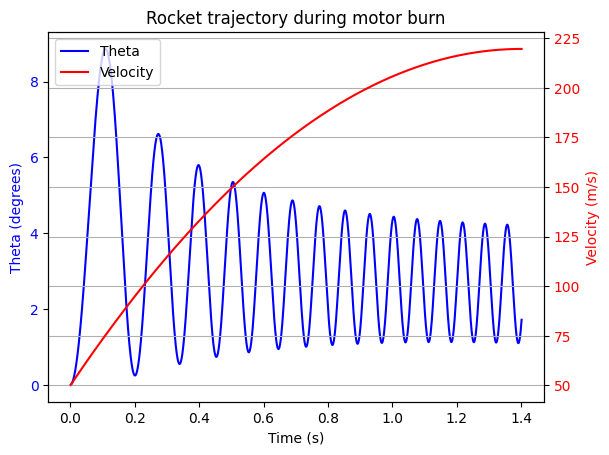

In [2]:
import math
import matplotlib.pyplot as plt

mass = 3.3 #kg
body_diameter = 0.102 #m
body_length = 1.14 #m
motor_offset = 0.025 #m
cp_cg_distance = 0.068 #m

moment_of_inertia = mass * body_length**2 / 12 # kg*m^2, assuming a thin uniform rod

air_density = 1.225 #kg/m^3
Cn = 12.73 #1/rad; coefficient of restoring torque as a function of angle, taken from open rocket

#Motor properties
motor_burn = 1.4 #s
motor_max_thrust = 800 #N
def get_motor_thrust(t): #Assumes a linear from max thrust to 0 over the burn time
    if t > motor_burn:
        return 0
    return motor_max_thrust * (1 - t/motor_burn)

def get_motor_torque(t): #Nm
    return get_motor_thrust(t) * motor_offset

def get_aero_angle_of_attack(theta, omega, velocity_x, velocity_y):
    velocity_angle = math.atan2(velocity_x, velocity_y)
    aoa = theta - velocity_angle
    return aoa


def get_restoring_torque(theta, omega, velocity, aoa):
    wetted_cross_section = body_diameter * body_length
    aero_force = 0.5 * air_density * velocity**2 * wetted_cross_section * Cn * aoa
    torque_restoring = aero_force * cp_cg_distance
    return torque_restoring

#Solve for the angle with numerical integration
dt = 0.001 #s
t = 0
theta = 0
omega = 0
alpha = 0
velocity = 50 #m/s, accounts for off the rail speed
velocity_x = velocity * math.sin(theta)
velocity_y = velocity * math.cos(theta)


theta_list = []
velocity_list = []
time_list = []
motor_torque_list = []
restoring_torque_list = []
net_torque_list = []

while t < motor_burn:
    thrust = get_motor_thrust(t)
    thrust_x = thrust * math.sin(theta)
    thrust_y = thrust * math.cos(theta)
    
    acceleration_x = thrust_x / mass
    acceleration_y = thrust_y / mass
    velocity_x += acceleration_x * dt
    velocity_y += acceleration_y * dt
    velocity = math.hypot(velocity_x, velocity_y)
    
    aoa = get_aero_angle_of_attack(theta, omega, velocity_x, velocity_y)
    
    restoring_torque = get_restoring_torque(theta, omega, velocity, aoa)
    
    torque = get_motor_torque(t) - restoring_torque
    alpha = torque / moment_of_inertia
    omega += alpha * dt
    theta += omega * dt
    
    t += dt

    theta_list.append(math.degrees(theta))
    velocity_list.append(velocity)
    time_list.append(t)
    motor_torque_list.append(get_motor_torque(t))
    restoring_torque_list.append(restoring_torque)
    net_torque_list.append(get_motor_torque(t) - restoring_torque)



fig, ax1 = plt.subplots()

ax1.set_xlabel('Time (s)')
ax1.set_ylabel('Theta (degrees)', color='blue')
line1, = ax1.plot(time_list, theta_list, color='blue', label='Theta')  # Store the line for legend
ax1.tick_params(axis='y', labelcolor='blue')

ax2 = ax1.twinx() 
ax2.set_ylabel('Velocity (m/s)', color='red') 
line2, = ax2.plot(time_list, velocity_list, color='red', label='Velocity')  
ax2.tick_params(axis='y', labelcolor='red')

# ax3 = ax1.twinx()
# ax3.spines['right'].set_position(('outward', 60)) 
# ax3.set_ylabel('Torque (Nm)', color='green')
# line3, = ax3.plot(time_list, motor_torque_list, color='green', label='Motor Torque')  # Store the line for legend
# line4, = ax3.plot(time_list, restoring_torque_list, color='orange', label='Restoring Torque')  # Store the line for legend
# line5, = ax3.plot(time_list, net_torque_list, color='purple', label='Net Torque')  # Store the line for legend
# ax3.tick_params(axis='y', labelcolor='green')

lines = [line1, line2]
labels = [line.get_label() for line in lines]

ax1.legend(lines, labels, loc='upper left')

plt.title('Rocket trajectory during motor burn')
plt.grid(True)

plt.show()
